<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Dynamique-du-taux-court" data-toc-modified-id="Dynamique-du-taux-court-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Dynamique du taux court</a></span><ul class="toc-item"><li><span><a href="#Solution-analytique" data-toc-modified-id="Solution-analytique-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Solution analytique</a></span></li><li><span><a href="#Simulation-exacte" data-toc-modified-id="Simulation-exacte-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Simulation exacte</a></span></li></ul></li><li><span><a href="#Prix-zéro-coupon" data-toc-modified-id="Prix-zéro-coupon-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Prix zéro-coupon</a></span><ul class="toc-item"><li><span><a href="#Formules-analytiques" data-toc-modified-id="Formules-analytiques-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Formules analytiques</a></span></li><li><span><a href="#Evolution-temporelle-du-prix-zéro-coupon-(en-fonction-de-celle-du-taux-court)" data-toc-modified-id="Evolution-temporelle-du-prix-zéro-coupon-(en-fonction-de-celle-du-taux-court)-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Evolution temporelle du prix zéro-coupon (en fonction de celle du taux court)</a></span></li><li><span><a href="#Courbe-des-taux" data-toc-modified-id="Courbe-des-taux-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Courbe des taux</a></span><ul class="toc-item"><li><span><a href="#Illustrations-des-formes-possibles" data-toc-modified-id="Illustrations-des-formes-possibles-2.3.1"><span class="toc-item-num">2.3.1&nbsp;&nbsp;</span>Illustrations des formes possibles</a></span></li><li><span><a href="#Sensibilités-aux-paramètres" data-toc-modified-id="Sensibilités-aux-paramètres-2.3.2"><span class="toc-item-num">2.3.2&nbsp;&nbsp;</span>Sensibilités aux paramètres</a></span></li></ul></li><li><span><a href="#Confrontation-aux-données-de-marché" data-toc-modified-id="Confrontation-aux-données-de-marché-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Confrontation aux données de marché</a></span><ul class="toc-item"><li><span><a href="#Récupération-des-données-de-marché" data-toc-modified-id="Récupération-des-données-de-marché-2.4.1"><span class="toc-item-num">2.4.1&nbsp;&nbsp;</span>Récupération des données de marché</a></span></li><li><span><a href="#Analyse-descriptive" data-toc-modified-id="Analyse-descriptive-2.4.2"><span class="toc-item-num">2.4.2&nbsp;&nbsp;</span>Analyse descriptive</a></span></li><li><span><a href="#Calibration" data-toc-modified-id="Calibration-2.4.3"><span class="toc-item-num">2.4.3&nbsp;&nbsp;</span>Calibration</a></span></li></ul></li></ul></li></ul></div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dynamique du taux court

Le modèle de taux court est donné par un processus d'Ornstein-Uhlenbeck:
$$dr_t=a(b-r_t)dt-\sigma dW_t$$
avec $r_0$ le taux court à $t=0$.

## Solution analytique

La solution $r_t$ est un processus gaussien donné par
\begin{equation}
r_t=r_0\,e^{-at}+b(1-e^{-at})-\sigma \int_0^te^{-a(t-s)}dW_s,\quad t\geq 0.
\end{equation}


In [2]:
# paramètres possibles
a=1
b=0.04
sigma=0.01
r0=0.03

## Simulation exacte

On souhaite simuler $r$ à des dates équidistantes, espacés du pas $\Delta=T/n$.

In [3]:
# paramètres
T=1
n=52
Delta=T/n

In [25]:
# on renvoie la trajectoire de r et les temps associés $t_i=i\Delta$
def simul_path_r(r0, a, b, sigma, Delta, n):
    path_r=np.array([r0])
    grille_temps=np.array([0])
    r_previous=r0
    for i in range(n):
        r_next= r_previous + a*(b - r_previous)*Delta - sigma*np.sqrt(Delta)*np.random.normal()
        r_previous=r_next
        path_r=np.append(path_r,r_next)
        grille_temps=np.append(grille_temps,(i+1)*Delta)
    return (path_r, grille_temps)

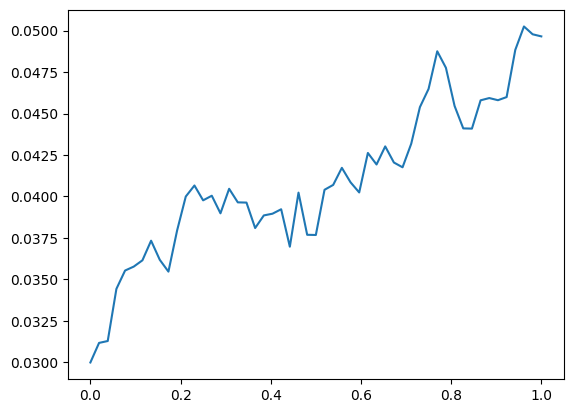

In [36]:
path_r, grille_temps=simul_path_r(r0, a, b, sigma, Delta, n)
plt.plot(grille_temps, path_r)

# Prix zéro-coupon

## Formules analytiques

En partant de $$B(t,T)=\mathbb{E}_{\mathbb Q}\left[\exp\big(-\int_t^Tr_sds\big)|{\cal F}_t\right],$$ on obtient
$$B(t,T)=\exp-\left[R_{\infty}(T-t) -(R_{\infty }-r_t)
\frac{1-e^{-a(T-t) }}{a}+\frac{\sigma ^2}{4a^3}(1-e^{-a(T-t)})^2\right]$$
avec $$R_{\infty }= b-\frac{\sigma^2}{2a^2}.$$
A la date $t$, le taux continu avec tenor $\theta$ est noté $R(t,\theta)$ et défini par
$$B(t,t+\theta)=\exp(-\theta\, R(t,\theta)).$$
Cela donne 
$$R(t,\theta)=R_{\infty}-(R_{\infty }-r_t)\frac{1-e^{-a\theta
}}{a\theta }+\frac{\sigma ^2}{4a^3\theta }(1-e^{-a\theta })^2.$$

In [30]:
def taux_long_Vasicek(a, b, sigma):
    return b - (sigma**2)/(2*a**2)

def taux_continu_Vasicek(t, theta, rt, Rinfty, a, sigma):
    return Rinfty - (Rinfty - rt)*(1 - np.exp(-a*theta))/(a*theta) + (sigma**2)/(4*a**3)*(1 - np.exp(-a*theta))**2
 
def zero_coupon_price_Vasicek(t, T, rt, Rinfty, a, sigma):
    theta=T-t # tenor
    return np.exp(-taux_continu_Vasicek(t, theta, rt, Rinfty, a, sigma)*theta)

## Evolution temporelle du prix zéro-coupon (en fonction de celle du taux court)

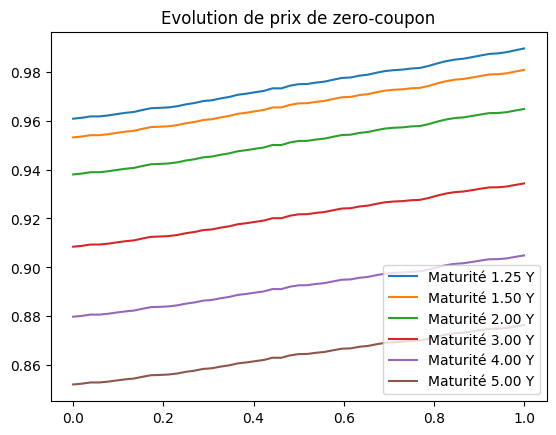

In [64]:
Rinfty=taux_long_Vasicek(a, b, sigma)
plt.title("Evolution de prix de zero-coupon")
for Ti in np.array([1.25,1.5,2, 3, 4, 5]):
    plt.plot(grille_temps, zero_coupon_price_Vasicek(grille_temps, Ti, path_r, Rinfty, a, sigma), label='Maturité %1.2f Y'%Ti)
plt.legend()

<h5><p style="font-size:20px; ">Qu'observe t'on?</h5>

## Courbe des taux

### Illustrations des formes possibles

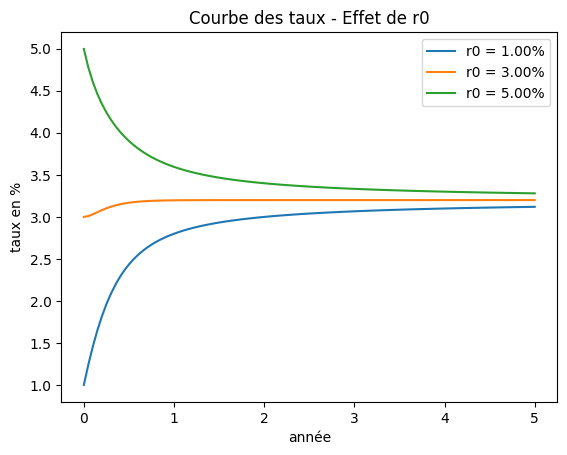

In [65]:
plt.title("Courbe des taux - Effet de r0")
plt.ylabel('taux en %')
plt.xlabel('année')
tenor=np.linspace(0.001,5,100)
a=5
b=0.05
sigma=1
Rinfty=taux_long_Vasicek(a, b, sigma)
for r0_tmp in np.array([Rinfty-0.02,Rinfty,Rinfty+0.02]):
    plt.plot(tenor, 100*taux_continu_Vasicek(0.0, tenor, r0_tmp, Rinfty, a, sigma), label="r0 = %2.2f%%"%(r0_tmp*100))
plt.legend()

<h5><p style="font-size:20px; ">Qu'observe t'on?</h5>

### Sensibilités aux paramètres

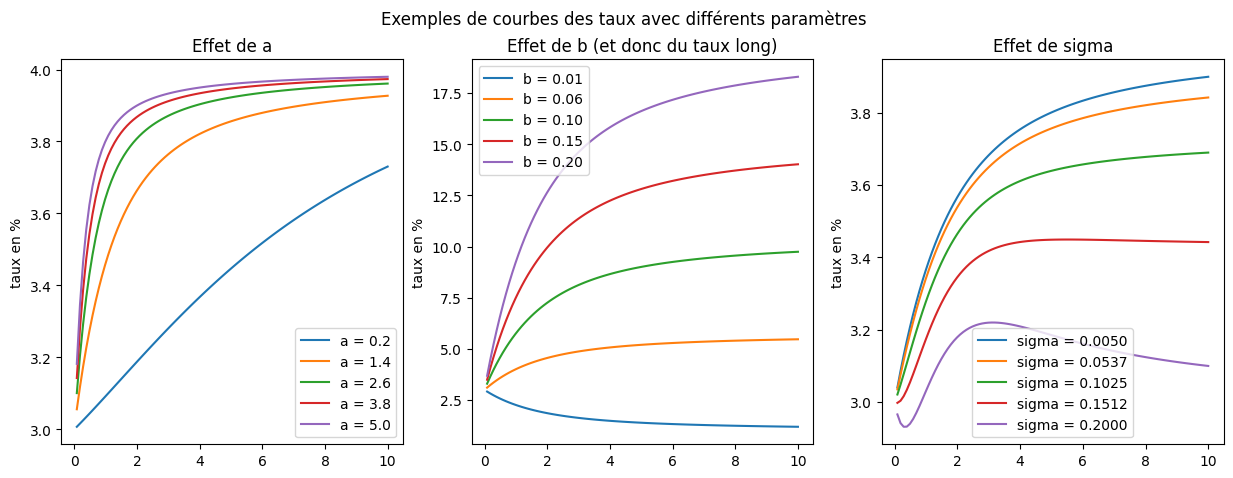

In [13]:
a=1
b=0.04
sigma=0.01
r0=0.03

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Exemples de courbes des taux avec différents paramètres")

ax1.set_title("Effet de a")
tenor=np.linspace(1/12,10,100)
ax1.set_ylabel('taux en %')
for a_tmp in np.linspace(0.2,5,5):
    Rinfty_tmp=taux_long_Vasicek(a_tmp, b, sigma)
    ax1.plot(tenor, 100*taux_continu_Vasicek(0.0, tenor, r0, Rinfty_tmp, a_tmp, sigma), label="a = %1.1f"%a_tmp)
ax1.legend()

ax2.set_title("Effet de b (et donc du taux long)")
tenor=np.linspace(1/12,10,100)
ax2.set_ylabel('taux en %')
for b_tmp in np.linspace(0.01,0.2,5):
    Rinfty_tmp=taux_long_Vasicek(a, b_tmp, sigma)
    ax2.plot(tenor, 100*taux_continu_Vasicek(0.0, tenor, r0, Rinfty_tmp, a, sigma), label="b = %0.2f"%b_tmp)
ax2.legend()

ax3.set_title("Effet de sigma")
tenor=np.linspace(1/12,10,100)
ax3.set_ylabel('taux en %')
for sigma_tmp in np.linspace(0.005,0.2,5):
    Rinfty_tmp=taux_long_Vasicek(a, b, sigma_tmp)
    ax3.plot(tenor, 100*taux_continu_Vasicek(0.0, tenor, r0, Rinfty_tmp, a, sigma_tmp), label="sigma = %0.4f"%sigma_tmp)
ax3.legend()


## Confrontation aux données de marché

### Récupération des données de marché

In [68]:
# data provenant de Deutsche Bundesbank
# https://www.bundesbank.de/dynamic/action/en/statistics/time-series-databases/time-series-databases/743796/743796?openNodeId=1745256&treeAnchor=GELD
# Money market rates (tenor=1 mois) + Yields (tenor=XX années)
import pandas as pd
df = pd.read_excel('HistoricalInterestRate_Europe.xlsx') 
df

,timestamp,M1,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,...,Y21,Y22,Y23,Y24,Y25,Y26,Y27,Y28,Y29,Y30
0,2000-01,3.150,3.97,4.47,4.82,5.06,5.23,5.36,5.45,5.52,...,5.94,5.96,5.98,6.00,6.02,6.04,6.06,6.07,6.09,6.10
1,2000-02,3.360,4.07,4.50,4.81,5.02,5.17,5.28,5.36,5.43,...,5.80,5.82,5.83,5.85,5.87,5.88,5.89,5.91,5.92,5.93
2,2000-03,3.590,4.16,4.47,4.70,4.85,4.97,5.06,5.12,5.18,...,5.55,5.57,5.58,5.60,5.62,5.63,5.65,5.66,5.68,5.69
3,2000-04,3.790,4.43,4.69,4.86,4.99,5.10,5.19,5.26,5.32,...,5.62,5.63,5.63,5.64,5.65,5.65,5.66,5.66,5.67,5.67
4,2000-05,4.160,4.84,5.01,5.09,5.14,5.18,5.22,5.26,5.29,...,5.45,5.46,5.46,5.47,5.47,5.47,5.48,5.48,5.48,5.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,2023-07,3.470,3.39,3.08,2.81,2.63,2.54,2.50,2.49,2.49,...,2.62,2.62,2.61,2.60,2.60,2.59,2.58,2.57,2.56,2.54
283,2023-08,3.630,3.34,2.99,2.71,2.56,2.48,2.45,2.45,2.46,...,2.63,2.63,2.63,2.62,2.62,2.61,2.60,2.59,2.58,2.57
284,2023-09,3.760,3.58,3.19,2.93,2.81,2.77,2.77,2.78,2.81,...,3.01,3.01,3.01,3.00,3.00,3.00,2.99,2.98,2.97,2.97
285,2023-10,3.860,3.47,3.01,2.75,2.64,2.62,2.64,2.67,2.71,...,3.02,3.02,3.03,3.03,3.02,3.02,3.02,3.01,3.01,3.00


### Analyse descriptive

           M1        Y1        Y5       Y10       Y30
M1   1.000000  0.976324  0.931791  0.889714  0.857278
Y1   0.976324  1.000000  0.961319  0.910402  0.869246
Y5   0.931791  0.961319  1.000000  0.985448  0.960882
Y10  0.889714  0.910402  0.985448  1.000000  0.991812
Y30  0.857278  0.869246  0.960882  0.991812  1.000000


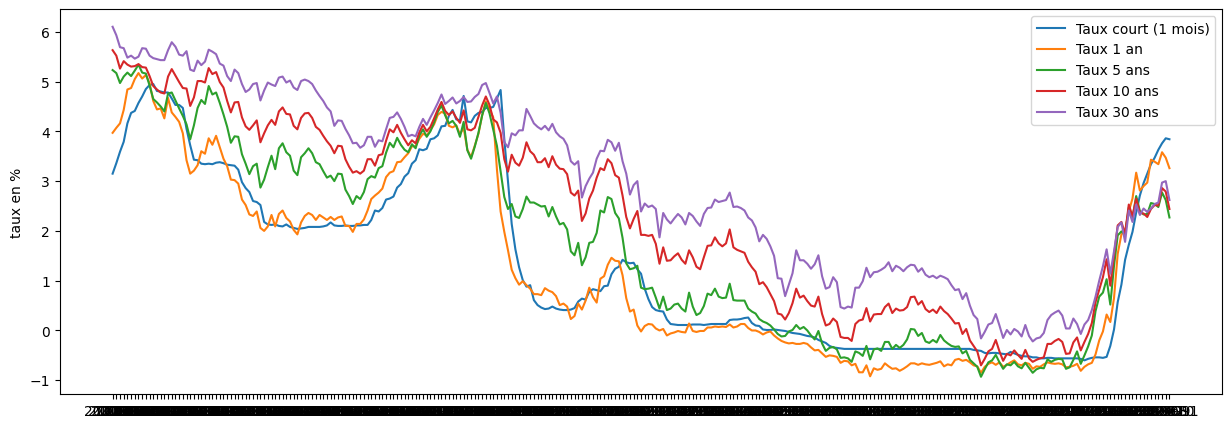

In [73]:
plt.figure(figsize=(15,5))
plt.plot(df.timestamp, df['M1'], label="Taux court (1 mois)")
plt.plot(df.timestamp, df['Y1'], label="Taux 1 an")
plt.plot(df.timestamp, df['Y5'], label="Taux 5 ans")
plt.plot(df.timestamp, df['Y10'], label="Taux 10 ans")
plt.plot(df.timestamp, df['Y30'], label="Taux 30 ans")
plt.ylabel('taux en %')
plt.legend()

correlations = df[['M1', 'Y1', 'Y5', 'Y10', 'Y30']].corr()
print(correlations)

<h5><p style="font-size:20px; ">Qu'observe t'on?</h5>

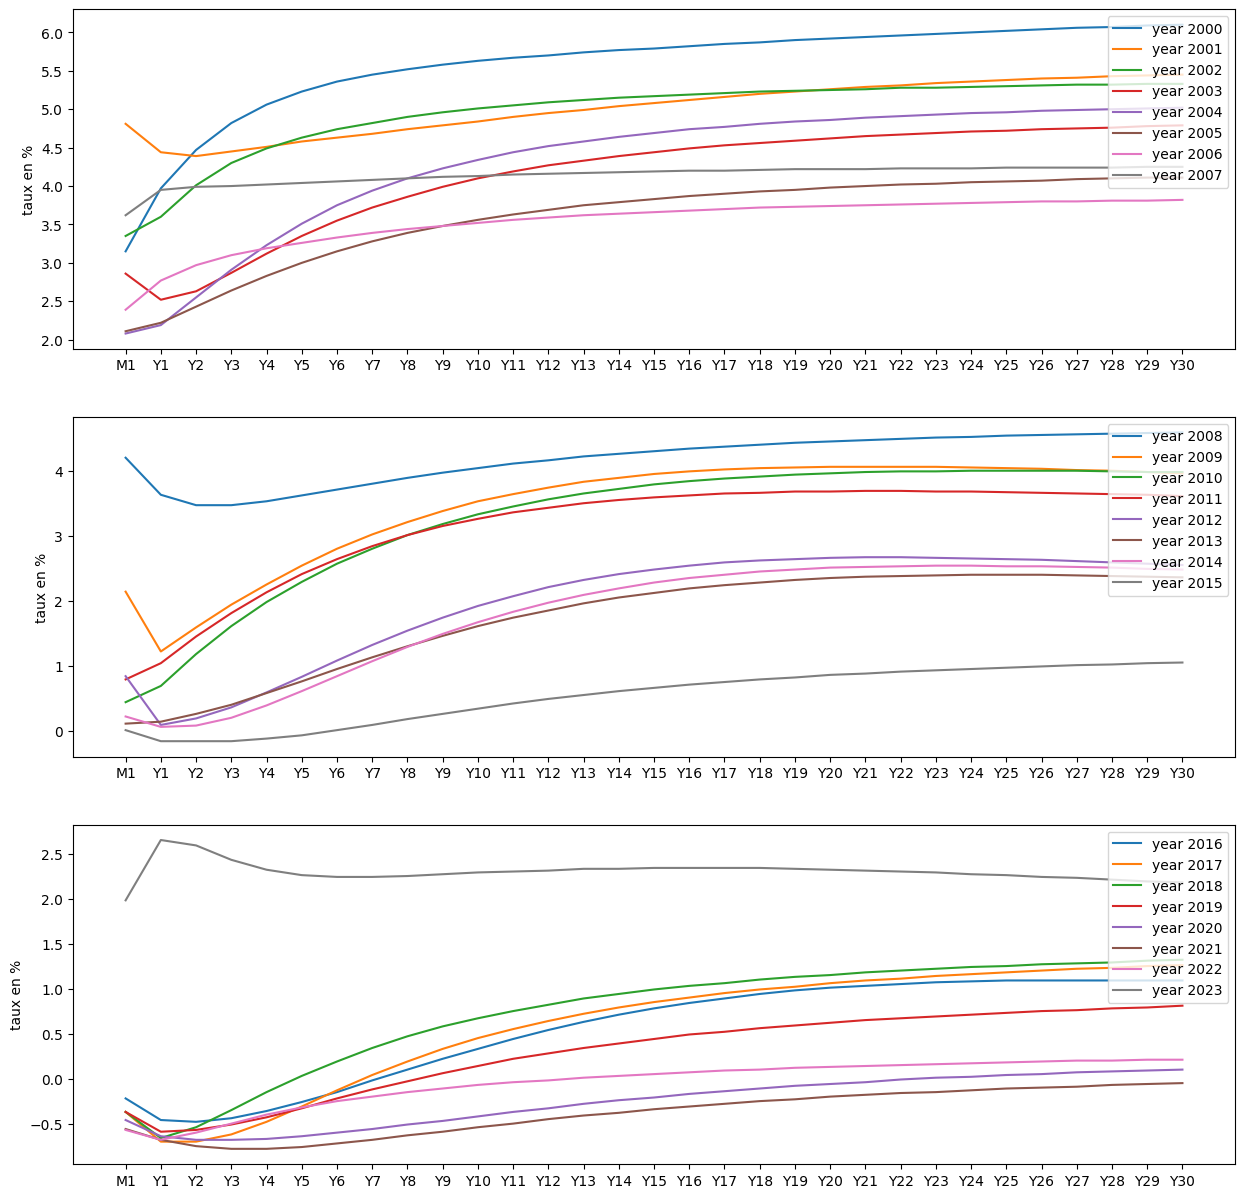

In [71]:
# trace des courbes des taux au mois de janvier, de 2000 à 2023, par paquet de 8 ans
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 15))
tenors = list(df)[1:] 
for year in range(2000, 2008, 1):
    ax1.plot(tenors, df[df.timestamp=="%d-01"%year].iloc[0].values[1:], label="year %d"%year)
    ax2.plot(tenors, df[df.timestamp=="%d-01"%(year+8)].iloc[0].values[1:], label="year %d"%(year+8))
    ax3.plot(tenors, df[df.timestamp=="%d-01"%(year+16)].iloc[0].values[1:], label="year %d"%(year+16))
for ax in (ax1,ax2,ax3):
    ax.set_ylabel('taux en %')
    ax.legend(loc=1)

<h5><p style="font-size:20px; ">Qu'observe t'on?</h5>

### Calibration
Nous cherchons les paramètres $(r_t, R_\infty, a, \sigma)$ tels que la courbe des taux Vasicek est la plus proche de celle observée. Pour cela, nous cherchons à minimiser un critère de moindres carrés et nous testons 2 méthodes:

* une méthode où seuls $(R_\infty, a, \sigma)$ sont optimisés (et $r_t$ est donné par le taux court observé)

* une méthode où les 4 paramètres $(r_t,R_\infty, a, \sigma)$ sont optimisés

In [75]:
# la fonction à minimiser comme fonction de x=(rt, Rinfty, a, sigma) de dimension 4
# attention, il faut bien penser à diviser les taux des data (en %) par 100
def function_to_minimize_least_squares(x, data_tenor, data_taux_continu): 
    tmp=0
    for i in range(len(data_tenor)):
        model_rate = taux_continu_Vasicek(0.0, data_tenor[i], x[0], x[1], x[2], x[3])
        tmp += (model_rate - data_taux_continu[i]/100)**2
    return tmp

In [ ]:
# différents dates pour tester la calibration
timestamp_calibration="2000-01" # ex. de courbe croissante
timestamp_calibration="2023-06" # ex. de courbe décroissante
timestamp_calibration="2023-11" # ex. de courbe inversée avec deux bosses
timestamp_calibration="2021-01" # ex. de courbe inversée puis croissante

data_taux_continu=df[df.timestamp==timestamp_calibration].iloc[0].values[1:]
data_tenor=np.linspace(0.0,30.0, 31)
data_tenor[0]=1.0/12

# initial guess pour la calibration
rt_init =  data_taux_continu[0]/100
Rinfty_init = data_taux_continu[-1]/100
a_init = 0.1
sigma_init = 0.01

Vasicek_parameter_init    = np.array([rt_init, Rinfty_init, a_init, sigma_init]) 
print("Paramètres initiaux:", Vasicek_parameter_init)

Paramètres initiaux: [0.03841 0.0262  0.1     0.01   ]


Paramètres finaux (avec rt fixe)    : [3.84100000e-02 2.52797813e-02 2.91268084e+00 1.00000000e-04]
Paramètres finaux (avec rt optimisé): [4.06277874e-02 2.53054596e-02 3.63613322e+00 1.00000000e-04]


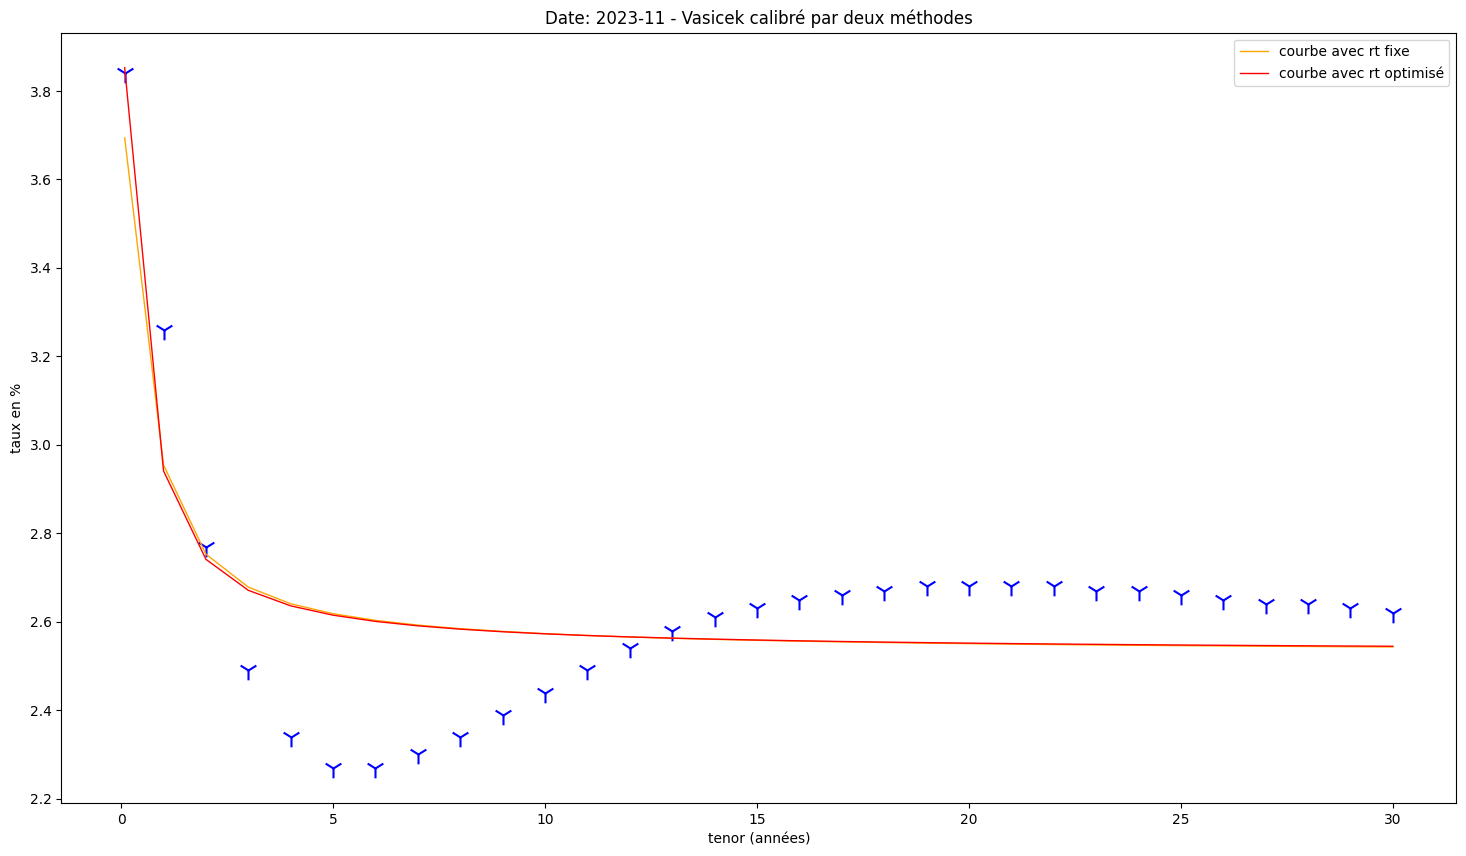

In [83]:
import scipy.optimize as optimization # pour l'optimisation dans la calibration
plt.figure(figsize=(18,10))
plt.title("Date: %s - Vasicek calibré par deux méthodes"%timestamp_calibration)
plt.xlabel("tenor (années)")
plt.ylabel("taux en %")

# calibration en laissant rt fixe
result=optimization.minimize(function_to_minimize_least_squares, args=(data_tenor, data_taux_continu), 
                             x0=Vasicek_parameter_init, method='L-BFGS-B', tol=1E-16,
                             bounds=[(rt_init, rt_init),
                                     (0.0,0.2), 
                                     (0.0001, 10), 
                                     (0.0001, 10)])  
rt, Rinfty, a, sigma = result['x']
print("Paramètres finaux (avec rt fixe)    :", result['x'])
plt.plot(data_tenor, 100*taux_continu_Vasicek(t=0, theta=data_tenor, rt=rt, Rinfty=Rinfty, a=a, sigma=sigma), 
         lw=1, color="orange", label="courbe avec rt fixe")

# calibration en optimisant rt 
result=optimization.minimize(function_to_minimize_least_squares, args=(data_tenor, data_taux_continu), 
                             x0=Vasicek_parameter_init, method='L-BFGS-B', tol=1E-16,
                             bounds=[(-0.1, 0.2),
                                     (0.0,0.2), 
                                     (0.0001, 10), 
                                     (0.0001, 10)])  
rt, Rinfty, a, sigma = result['x']
print("Paramètres finaux (avec rt optimisé):", result['x'])
plt.plot(data_tenor, 100*taux_continu_Vasicek(t=0, theta=data_tenor, rt=rt, Rinfty=Rinfty, a=a, sigma=sigma), 
         lw=1, color="red", label="courbe avec rt optimisé")
plt.scatter(data_tenor, data_taux_continu, s=200, marker="1", color="blue")
plt.legend()